# 11 — Real-Time AML Transaction Simulator

Live transaction stream with **real-time GraphSAGE + WGAN-GP scoring**.

```
TransactionStream          LiveGraph              RealtimeScorer
  (yields txns)  ──────►  (maintains state)  ──►  (scores nodes)
       │                       │                        │
  normal + pattern      node features [N,9]      anomaly scores
  generation            edge_index [2,E]          alert log
                        affected_nodes set         risk flags
                              │
                    ┌─────────┴──────────┐
                    ▼                    ▼
              GraphSAGE              WGAN-GP
           (full forward)       (anomaly_score)
              [N,64]               [batch,]
```

### Prerequisites
Run notebooks **01–05** first to generate model artifacts in `models/` and `data/`.

In [ ]:
# ── Imports & GPU Safety ──
import os, json, time, gc, math
from datetime import datetime, timedelta
from collections import deque, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

from IPython.display import display, clear_output
from gan_anomaly import Generator, Encoder, anomaly_score

# GPU cleanup from any previous notebook
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.memory_allocated()/1e6:.1f} MB allocated")

# ── Pipeline integration ──────────────────────────────────────────
_RUN_DIR = os.environ.get("AML_RUN_DIR", "")
DATA_DIR = os.path.join(_RUN_DIR, "data") if _RUN_DIR else "data"
MODELS_DIR = os.path.join(_RUN_DIR, "models") if _RUN_DIR else "models"
RESULTS_DIR = os.path.join(_RUN_DIR, "results") if _RUN_DIR else "results"
SIM_DIR = os.path.join(RESULTS_DIR, "simulation")
os.makedirs(SIM_DIR, exist_ok=True)

print(f"RUN_DIR: {_RUN_DIR or '(local)'}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"MODELS_DIR: {MODELS_DIR}")
print(f"SIM_DIR: {SIM_DIR}")

In [2]:
# ═══════════════════════════════════════════════════════════
#  CONFIGURATION
# ═══════════════════════════════════════════════════════════

SEED = 42

# ── Simulation ──
BATCH_SIZE = 50              # transactions per batch
BATCH_INTERVAL = 0.5         # seconds between batches (display refresh)
NUM_BATCHES = 80             # total batches to simulate
PATTERN_PROB = 0.10          # probability of injecting a pattern per batch

# ── Scoring ──
RESCORE_INTERVAL = 3         # re-run GraphSAGE every N batches (amortize cost)
THRESHOLD_PERCENTILE = 99    # training score percentile for anomaly flag

# ── Display ──
ALERT_HISTORY = 200          # max alerts kept in rolling buffer
SCORE_HISTORY = 200          # rolling batch score history

# ── Transaction generation (same as NB 00) ──
AMOUNT_MU = 6.2
AMOUNT_SIGMA = 0.4
AMOUNT_MIN = 40.0
AMOUNT_MAX = 3_000.0
TX_TYPES = ["TRANSFER-Mutual", "TRANSFER-FanOut", "TRANSFER-Forward", "TRANSFER-Periodical", "TRANSFER-FanIn"]
TX_PROBS = np.array([0.31, 0.26, 0.22, 0.19, 0.02])
TX_PROBS /= TX_PROBS.sum()

# ── Pattern injection ──
FAN_MIN_LEGS = 4
FAN_MAX_LEGS = 8
PATTERN_AMT_MIN = 500
PATTERN_AMT_MAX = 3_000
STRUCTURING_NUM_TXNS = 8
STRUCTURING_AMT_MIN = 7_000
STRUCTURING_AMT_MAX = 9_500

rng = np.random.default_rng(SEED)

print(f"Config: {NUM_BATCHES} batches × {BATCH_SIZE} txns = {NUM_BATCHES * BATCH_SIZE:,} total txns")
print(f"Scoring: every {RESCORE_INTERVAL} batches, threshold P{THRESHOLD_PERCENTILE}")
print(f"Pattern injection: {PATTERN_PROB*100:.0f}% chance per batch")

Config: 80 batches × 50 txns = 4,000 total txns
Scoring: every 3 batches, threshold P99
Pattern injection: 10% chance per batch


In [3]:
# ═══════════════════════════════════════════════════════════
#  GraphSAGE Model Definition (same as NB 02)
# ═══════════════════════════════════════════════════════════

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    @torch.no_grad()
    def full_forward(self, x, edge_index):
        self.eval()
        return self.forward(x, edge_index)

print("GraphSAGE class defined (SAGEConv 9→128→64)")

GraphSAGE class defined (SAGEConv 9→128→64)


In [4]:
# ═══════════════════════════════════════════════════════════
#  TransactionStream — generates live transaction batches
# ═══════════════════════════════════════════════════════════

class TransactionStream:
    """Simulates a live transaction feed with optional laundering patterns."""

    PATTERN_TYPES = ["fan_out", "fan_in", "cycle", "scatter_gather", "structuring"]

    def __init__(self, party_ids, rng, pattern_prob=0.10):
        self.party_ids = list(party_ids)
        self.n_parties = len(self.party_ids)
        self.rng = rng
        self.pattern_prob = pattern_prob
        self.tran_counter = 1_000_000  # start IDs above existing range
        self.alert_counter = 500
        self.base_time = datetime.now()
        self.batch_num = 0
        self.total_patterns_injected = 0

    def _pick(self, n, exclude=None):
        pool = self.party_ids if exclude is None else [p for p in self.party_ids if p not in exclude]
        return self.rng.choice(pool, size=min(n, len(pool)), replace=False).tolist()

    def _ts(self):
        offset = timedelta(seconds=self.batch_num * 30 + int(self.rng.integers(0, 30)))
        return (self.base_time + offset).strftime("%Y-%m-%dT%H:%M:%S.000Z")

    def _amt(self, low=PATTERN_AMT_MIN, high=PATTERN_AMT_MAX):
        return round(float(self.rng.uniform(low, high)), 2)

    def _next_id(self):
        self.tran_counter += 1
        return self.tran_counter

    def _make_normal_txns(self, n):
        src_idx = self.rng.zipf(a=1.5, size=n) % self.n_parties
        dst_idx = self.rng.zipf(a=1.3, size=n) % self.n_parties
        self_loops = src_idx == dst_idx
        dst_idx[self_loops] = (dst_idx[self_loops] + 1) % self.n_parties

        amounts = self.rng.lognormal(AMOUNT_MU, AMOUNT_SIGMA, size=n)
        amounts = np.clip(amounts, AMOUNT_MIN, AMOUNT_MAX).round(2)
        tx_types = self.rng.choice(TX_TYPES, size=n, p=TX_PROBS)

        txns = []
        for i in range(n):
            txns.append({
                "tran_id": self._next_id(),
                "tx_type": tx_types[i],
                "base_amt": float(amounts[i]),
                "tran_timestamp": self._ts(),
                "src": self.party_ids[src_idx[i]],
                "dst": self.party_ids[dst_idx[i]],
                "_is_pattern": False,
                "_alert_type": None,
                "_alert_id": None,
            })
        return txns

    def _inject_fan_out(self):
        n_legs = int(self.rng.integers(FAN_MIN_LEGS, FAN_MAX_LEGS + 1))
        parties = self._pick(1 + n_legs)
        sender, receivers = parties[0], parties[1:]
        aid = self.alert_counter; self.alert_counter += 1
        txns = []
        for recv in receivers:
            txns.append({
                "tran_id": self._next_id(), "tx_type": "TRANSFER-FanOut",
                "base_amt": self._amt(), "tran_timestamp": self._ts(),
                "src": sender, "dst": recv,
                "_is_pattern": True, "_alert_type": "fan_out", "_alert_id": aid,
            })
        return txns

    def _inject_fan_in(self):
        n_legs = int(self.rng.integers(FAN_MIN_LEGS, FAN_MAX_LEGS + 1))
        parties = self._pick(1 + n_legs)
        receiver, senders = parties[0], parties[1:]
        aid = self.alert_counter; self.alert_counter += 1
        txns = []
        for s in senders:
            txns.append({
                "tran_id": self._next_id(), "tx_type": "TRANSFER-FanIn",
                "base_amt": self._amt(), "tran_timestamp": self._ts(),
                "src": s, "dst": receiver,
                "_is_pattern": True, "_alert_type": "fan_in", "_alert_id": aid,
            })
        return txns

    def _inject_cycle(self):
        a, b, c = self._pick(3)
        aid = self.alert_counter; self.alert_counter += 1
        base = self._amt()
        txns = []
        for s, d in [(a, b), (b, c), (c, a)]:
            txns.append({
                "tran_id": self._next_id(), "tx_type": "TRANSFER-Forward",
                "base_amt": round(base * float(self.rng.uniform(0.90, 1.10)), 2),
                "tran_timestamp": self._ts(), "src": s, "dst": d,
                "_is_pattern": True, "_alert_type": "cycle", "_alert_id": aid,
            })
        return txns

    def _inject_scatter_gather(self):
        n_mids = 4
        parties = self._pick(2 + n_mids)
        source, collector = parties[0], parties[1]
        mids = parties[2:]
        aid = self.alert_counter; self.alert_counter += 1
        txns = []
        for mid in mids:
            amt = self._amt()
            txns.append({
                "tran_id": self._next_id(), "tx_type": "TRANSFER-FanOut",
                "base_amt": amt, "tran_timestamp": self._ts(),
                "src": source, "dst": mid,
                "_is_pattern": True, "_alert_type": "scatter_gather", "_alert_id": aid,
            })
            txns.append({
                "tran_id": self._next_id(), "tx_type": "TRANSFER-FanIn",
                "base_amt": round(amt * float(self.rng.uniform(0.90, 0.95)), 2),
                "tran_timestamp": self._ts(), "src": mid, "dst": collector,
                "_is_pattern": True, "_alert_type": "scatter_gather", "_alert_id": aid,
            })
        return txns

    def _inject_structuring(self):
        parties = self._pick(2)
        sender, recv = parties[0], parties[1]
        aid = self.alert_counter; self.alert_counter += 1
        txns = []
        for _ in range(STRUCTURING_NUM_TXNS):
            txns.append({
                "tran_id": self._next_id(), "tx_type": "TRANSFER-Periodical",
                "base_amt": self._amt(STRUCTURING_AMT_MIN, STRUCTURING_AMT_MAX),
                "tran_timestamp": self._ts(), "src": sender, "dst": recv,
                "_is_pattern": True, "_alert_type": "structuring", "_alert_id": aid,
            })
        return txns

    def next_batch(self, size=50):
        """Generate next batch of transactions."""
        self.batch_num += 1
        txns = self._make_normal_txns(size)

        # Random pattern injection
        if self.rng.random() < self.pattern_prob:
            ptype = self.rng.choice(self.PATTERN_TYPES)
            injector = {
                "fan_out": self._inject_fan_out,
                "fan_in": self._inject_fan_in,
                "cycle": self._inject_cycle,
                "scatter_gather": self._inject_scatter_gather,
                "structuring": self._inject_structuring,
            }[ptype]
            pattern_txns = injector()
            txns.extend(pattern_txns)
            self.total_patterns_injected += 1

        return txns

print("TransactionStream defined (5 pattern types)")

TransactionStream defined (5 pattern types)


In [ ]:
# ═══════════════════════════════════════════════════════════
#  LiveGraph — incremental graph state manager
# ═══════════════════════════════════════════════════════════

class LiveGraph:
    """Maintains graph state with O(k) incremental updates per batch."""

    FEATURE_COLS = [
        "type", "in_degree", "out_degree",
        "total_amount_sent", "total_amount_received",
        "avg_amount_sent", "avg_amount_received",
        "unique_counterparties_sent", "unique_counterparties_received",
    ]

    def __init__(self):
        # Load existing pipeline state
        nf = pd.read_parquet(os.path.join(DATA_DIR, "node_features.parquet"))
        edges_df = pd.read_parquet(os.path.join(DATA_DIR, "edges.parquet"))

        self.node_ids = list(nf["id"].values)
        self.node_to_idx = {nid: i for i, nid in enumerate(self.node_ids)}
        self.n_nodes = len(self.node_ids)

        # Running stats per node (initialized from pipeline data)
        self.node_type = {}
        self.out_degree = defaultdict(int)
        self.in_degree = defaultdict(int)
        self.total_sent = defaultdict(float)
        self.total_received = defaultdict(float)
        self.counterparties_sent = defaultdict(set)
        self.counterparties_received = defaultdict(set)

        for _, row in nf.iterrows():
            nid = row["id"]
            self.node_type[nid] = int(row["type"])
            self.out_degree[nid] = int(row["out_degree"])
            self.in_degree[nid] = int(row["in_degree"])
            self.total_sent[nid] = float(row["total_amount_sent"])
            self.total_received[nid] = float(row["total_amount_received"])
            # Counterparties: initialize count only (sets rebuilt approximately)
            self.counterparties_sent[nid] = set(range(int(row["unique_counterparties_sent"])))
            self.counterparties_received[nid] = set(range(int(row["unique_counterparties_received"])))

        # Edge set (deduplicated directed)
        self.edges = set()
        for _, row in edges_df.iterrows():
            src_idx = self.node_to_idx.get(row["source"])
            dst_idx = self.node_to_idx.get(row["target"])
            if src_idx is not None and dst_idx is not None:
                self.edges.add((src_idx, dst_idx))

        # SAR labels (ground truth)
        self.is_sar = {row["id"]: int(row.get("is_sar", 0)) for _, row in nf.iterrows()}

        # Tracking
        self.total_txns_processed = 0
        self.pattern_nodes = set()  # nodes involved in injected patterns

        print(f"LiveGraph initialized: {self.n_nodes:,} nodes, {len(self.edges):,} edges")

    def update(self, txn_batch):
        """Process a batch of transactions. Returns set of affected node indices."""
        affected = set()

        for txn in txn_batch:
            src = txn["src"]
            dst = txn["dst"]
            amt = txn["base_amt"]

            # Ensure nodes exist
            for nid in (src, dst):
                if nid not in self.node_to_idx:
                    idx = self.n_nodes
                    self.node_to_idx[nid] = idx
                    self.node_ids.append(nid)
                    self.n_nodes += 1
                    self.node_type[nid] = self.rng_type if hasattr(self, 'rng_type') else 0

            src_idx = self.node_to_idx[src]
            dst_idx = self.node_to_idx[dst]

            # Update running stats
            self.out_degree[src] += 1
            self.in_degree[dst] += 1
            self.total_sent[src] += amt
            self.total_received[dst] += amt
            self.counterparties_sent[src].add(dst_idx)
            self.counterparties_received[dst].add(src_idx)

            # Add edge
            self.edges.add((src_idx, dst_idx))

            # Track affected
            affected.add(src_idx)
            affected.add(dst_idx)

            # Track pattern nodes
            if txn.get("_is_pattern"):
                self.pattern_nodes.add(src)
                self.pattern_nodes.add(dst)
                self.is_sar[src] = 1
                self.is_sar[dst] = 1

        self.total_txns_processed += len(txn_batch)
        return affected

    def get_feature_matrix(self):
        """Build [N, 9] feature tensor from running stats."""
        features = np.zeros((self.n_nodes, 9), dtype=np.float32)
        for i, nid in enumerate(self.node_ids):
            od = self.out_degree[nid]
            ind = self.in_degree[nid]
            ts = self.total_sent[nid]
            tr = self.total_received[nid]
            features[i, 0] = self.node_type.get(nid, 0)
            features[i, 1] = ind
            features[i, 2] = od
            features[i, 3] = ts
            features[i, 4] = tr
            features[i, 5] = (ts / od) if od > 0 else 0.0
            features[i, 6] = (tr / ind) if ind > 0 else 0.0
            features[i, 7] = len(self.counterparties_sent[nid])
            features[i, 8] = len(self.counterparties_received[nid])
        return torch.tensor(features, dtype=torch.float32)

    def get_edge_index(self):
        """Build [2, E] edge index tensor."""
        if not self.edges:
            return torch.zeros((2, 0), dtype=torch.long)
        src_list, dst_list = zip(*self.edges)
        return torch.tensor([list(src_list), list(dst_list)], dtype=torch.long)

    def get_sar_labels(self):
        """Get SAR labels aligned with node order."""
        return np.array([self.is_sar.get(nid, 0) for nid in self.node_ids])

print("LiveGraph class defined (incremental O(k) updates)")

In [ ]:
# ═══════════════════════════════════════════════════════════
#  RealtimeScorer — loads models, scores nodes
# ═══════════════════════════════════════════════════════════

class RealtimeScorer:
    """Scores nodes using pre-trained GraphSAGE + WGAN-GP."""

    def __init__(self, device, threshold_pct=99):
        self.device = device

        # Load training meta
        with open(os.path.join(MODELS_DIR, "training_meta.json")) as f:
            self.meta = json.load(f)

        # Load GraphSAGE
        self.sage = GraphSAGE(9, 128, 64, dropout=0.3).to(device)
        self.sage.load_state_dict(torch.load(os.path.join(MODELS_DIR, "graphsage.pt"), map_location=device, weights_only=True))
        self.sage.eval()

        # Load WGAN-GP Encoder + Generator
        m = self.meta
        self.encoder = Encoder(m["input_dim"], m["latent_dim"], m["e_hidden"], m["n_layers"], m["activation"]).to(device)
        self.generator = Generator(m["latent_dim"], m["input_dim"], m["g_hidden"], m["n_layers"], m["activation"]).to(device)
        self.encoder.load_state_dict(torch.load(os.path.join(MODELS_DIR, "encoder.pt"), map_location=device, weights_only=True))
        self.generator.load_state_dict(torch.load(os.path.join(MODELS_DIR, "generator.pt"), map_location=device, weights_only=True))
        self.encoder.eval()
        self.generator.eval()

        # Load normalization
        norm = torch.load(os.path.join(MODELS_DIR, "feature_norm.pt"), map_location=device, weights_only=True)
        self.x_mean = norm["mean"].to(device)
        self.x_std = norm["std"].to(device)

        # Compute threshold from training data
        X_train = np.load(os.path.join(MODELS_DIR, "X_train.npy"))
        train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
        train_scores = anomaly_score(train_tensor, self.encoder, self.generator).cpu().numpy()
        self.threshold = float(np.percentile(train_scores, threshold_pct))
        del train_tensor, train_scores
        torch.cuda.empty_cache()

        # State
        self.all_scores = None       # cached scores [N,]
        self.all_embeddings = None   # cached embeddings [N, 64]
        self.alerts = deque(maxlen=ALERT_HISTORY)
        self.score_history = deque(maxlen=SCORE_HISTORY)  # (batch_num, mean, max, n_alerts)
        self.latency_history = []

        # Stats
        self.total_alerts = 0
        self.total_scored = 0

        print(f"RealtimeScorer ready")
        print(f"  Threshold (P{threshold_pct}): {self.threshold:.4f}")
        print(f"  Models: GraphSAGE + Encoder + Generator on {device}")

    def score(self, graph, affected_indices, batch_num, txn_batch):
        """Score all nodes, return results for affected nodes."""
        t0 = time.perf_counter()

        should_rescore = (batch_num % RESCORE_INTERVAL == 0) or (self.all_scores is None)

        if should_rescore:
            # Full GraphSAGE + WGAN-GP scoring
            x = graph.get_feature_matrix().to(self.device)
            edge_index = graph.get_edge_index().to(self.device)

            # Normalize
            # Handle size mismatch if graph grew beyond original normalization
            x_norm = (x - self.x_mean) / self.x_std

            # GraphSAGE forward
            embeddings = self.sage.full_forward(x_norm, edge_index)
            self.all_embeddings = embeddings.cpu()

            # WGAN-GP anomaly score
            scores = anomaly_score(embeddings, self.encoder, self.generator)
            self.all_scores = scores.cpu().numpy()

            # Free GPU tensors
            del x, edge_index, x_norm, embeddings, scores
            torch.cuda.empty_cache()

        latency_ms = (time.perf_counter() - t0) * 1000
        self.latency_history.append(latency_ms)

        # Extract results for affected nodes
        affected_list = sorted(affected_indices)
        batch_alerts = []

        if self.all_scores is not None:
            for idx in affected_list:
                if idx < len(self.all_scores):
                    score_val = float(self.all_scores[idx])
                    node_id = graph.node_ids[idx]
                    is_flagged = score_val > self.threshold

                    if is_flagged:
                        alert = {
                            "batch": batch_num,
                            "node_id": node_id,
                            "score": score_val,
                            "is_sar": graph.is_sar.get(node_id, 0),
                            "timestamp": datetime.now().strftime("%H:%M:%S"),
                        }
                        self.alerts.append(alert)
                        batch_alerts.append(alert)
                        self.total_alerts += 1

            self.total_scored += len(affected_list)

            # Record batch stats
            affected_scores = [self.all_scores[i] for i in affected_list if i < len(self.all_scores)]
            if affected_scores:
                self.score_history.append((
                    batch_num,
                    float(np.mean(affected_scores)),
                    float(np.max(affected_scores)),
                    len(batch_alerts),
                ))

        return {
            "batch_num": batch_num,
            "affected_count": len(affected_list),
            "alerts": batch_alerts,
            "latency_ms": latency_ms,
            "rescored": should_rescore,
        }

print("RealtimeScorer class defined")

In [8]:
# ═══════════════════════════════════════════════════════════
#  Live Dashboard — 4-panel display updated each batch
# ═══════════════════════════════════════════════════════════

def render_dashboard(scorer, graph, batch_num, result, txn_batch):
    """Render a 4-panel live dashboard."""
    clear_output(wait=True)

    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

    n_pattern = sum(1 for t in txn_batch if t.get("_is_pattern"))
    status = "RESCORING" if result["rescored"] else "cached"
    fig.suptitle(
        f"Real-Time AML Monitor — Batch {batch_num}/{NUM_BATCHES} | "
        f"{graph.total_txns_processed:,} txns | "
        f"{scorer.total_alerts} alerts | "
        f"{result['latency_ms']:.0f}ms [{status}]",
        fontsize=13, fontweight="bold"
    )

    # ── Panel 1: Score Time Series ──
    ax1 = fig.add_subplot(gs[0, 0])
    if scorer.score_history:
        batches = [s[0] for s in scorer.score_history]
        means = [s[1] for s in scorer.score_history]
        maxes = [s[2] for s in scorer.score_history]
        alerts_per = [s[3] for s in scorer.score_history]

        ax1.plot(batches, means, color="#4C72B0", linewidth=1.2, label="Mean score")
        ax1.fill_between(batches, means, alpha=0.15, color="#4C72B0")
        ax1.plot(batches, maxes, color="#DD4444", linewidth=0.8, alpha=0.6, label="Max score")
        ax1.axhline(scorer.threshold, color="orange", linestyle="--", linewidth=1, label=f"Threshold={scorer.threshold:.2f}")

        # Mark alert batches
        alert_batches = [b for b, _, _, a in scorer.score_history if a > 0]
        alert_maxes = [m for _, _, m, a in scorer.score_history if a > 0]
        if alert_batches:
            ax1.scatter(alert_batches, alert_maxes, color="red", s=30, zorder=5, marker="v")

    ax1.set_xlabel("Batch")
    ax1.set_ylabel("Anomaly Score")
    ax1.set_title("Score Time Series")
    ax1.legend(fontsize=8, loc="upper right")
    ax1.grid(True, alpha=0.2)

    # ── Panel 2: Alert Feed ──
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.axis("off")
    recent_alerts = list(scorer.alerts)[-12:]  # last 12
    if recent_alerts:
        header = f"{'Time':<10} {'Node':<10} {'Score':>8} {'SAR':>5}"
        rows = [header, "─" * 38]
        for a in reversed(recent_alerts):
            sar_mark = "YES" if a["is_sar"] else "no"
            rows.append(f"{a['timestamp']:<10} {a['node_id'][:8]:<10} {a['score']:>8.2f} {sar_mark:>5}")
        ax2.text(0.05, 0.95, "\n".join(rows), transform=ax2.transAxes,
                 fontsize=9, fontfamily="monospace", verticalalignment="top",
                 bbox=dict(boxstyle="round", facecolor="#FFF3CD", alpha=0.9))
    else:
        ax2.text(0.5, 0.5, "No alerts yet...", transform=ax2.transAxes,
                 ha="center", va="center", fontsize=12, color="gray")
    ax2.set_title(f"Alert Feed ({scorer.total_alerts} total)")

    # ── Panel 3: Confusion Matrix ──
    ax3 = fig.add_subplot(gs[1, 0])
    if scorer.all_scores is not None:
        sar_labels = graph.get_sar_labels()
        n_scores = min(len(scorer.all_scores), len(sar_labels))
        predicted = (scorer.all_scores[:n_scores] > scorer.threshold).astype(int)
        actual = sar_labels[:n_scores]

        tp = int(((predicted == 1) & (actual == 1)).sum())
        fp = int(((predicted == 1) & (actual == 0)).sum())
        fn = int(((predicted == 0) & (actual == 1)).sum())
        tn = int(((predicted == 0) & (actual == 0)).sum())

        cm = np.array([[tn, fp], [fn, tp]])
        im = ax3.imshow(cm, cmap="YlOrRd", aspect="auto")
        for i in range(2):
            for j in range(2):
                ax3.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=14, fontweight="bold")
        ax3.set_xticks([0, 1]); ax3.set_xticklabels(["Pred: Normal", "Pred: Anomaly"])
        ax3.set_yticks([0, 1]); ax3.set_yticklabels(["Actual: Normal", "Actual: SAR"])

        recall = tp / max(tp + fn, 1)
        precision = tp / max(tp + fp, 1)
        ax3.set_title(f"Confusion Matrix (P={precision:.2f} R={recall:.2f})")
    else:
        ax3.text(0.5, 0.5, "Waiting for first score...", transform=ax3.transAxes,
                 ha="center", va="center", fontsize=12, color="gray")
        ax3.set_title("Confusion Matrix")

    # ── Panel 4: Score Distribution ──
    ax4 = fig.add_subplot(gs[1, 1])
    if scorer.all_scores is not None:
        scores_clipped = np.clip(scorer.all_scores, 0, np.percentile(scorer.all_scores, 99.5))
        sar_mask = graph.get_sar_labels()[:len(scores_clipped)] == 1

        ax4.hist(scores_clipped[~sar_mask], bins=60, alpha=0.6, color="#4C72B0",
                 label=f"Normal ({(~sar_mask).sum():,})", density=True)
        if sar_mask.sum() > 0:
            ax4.hist(scores_clipped[sar_mask], bins=40, alpha=0.6, color="#DD4444",
                     label=f"SAR ({sar_mask.sum():,})", density=True)
        ax4.axvline(scorer.threshold, color="orange", linestyle="--", linewidth=1.5)
        ax4.legend(fontsize=8)
    ax4.set_xlabel("Anomaly Score")
    ax4.set_ylabel("Density")
    ax4.set_title("Score Distribution")
    ax4.grid(True, alpha=0.2)

    plt.show()

    # Print batch info below
    pattern_count = sum(1 for t in txn_batch if t.get("_is_pattern"))
    print(f"Batch {batch_num}: {len(txn_batch)} txns ({pattern_count} laundering) | "
          f"{result['affected_count']} nodes affected | "
          f"{len(result['alerts'])} new alerts | "
          f"{result['latency_ms']:.0f}ms")

print("Dashboard renderer defined (4-panel live display)")

Dashboard renderer defined (4-panel live display)


In [ ]:
# ═══════════════════════════════════════════════════════════
#  Initialize Components
# ═══════════════════════════════════════════════════════════

# Load party IDs from pipeline data (prefer DATA_DIR, fall back to demodata/)
_party_path = os.path.join(DATA_DIR, "party.csv")
if not os.path.exists(_party_path):
    _party_path = os.path.join("..", "demodata", "party.csv")
party_df = pd.read_csv(_party_path)
party_ids = party_df["partyId"].tolist()

stream = TransactionStream(party_ids, rng, pattern_prob=PATTERN_PROB)
graph = LiveGraph()
scorer = RealtimeScorer(device, threshold_pct=THRESHOLD_PERCENTILE)

print(f"\nReady to simulate {NUM_BATCHES} batches of {BATCH_SIZE} txns")
print(f"Estimated total: {NUM_BATCHES * BATCH_SIZE:,} normal + ~{int(NUM_BATCHES * PATTERN_PROB * 6)}-{int(NUM_BATCHES * PATTERN_PROB * 10)} pattern txns")

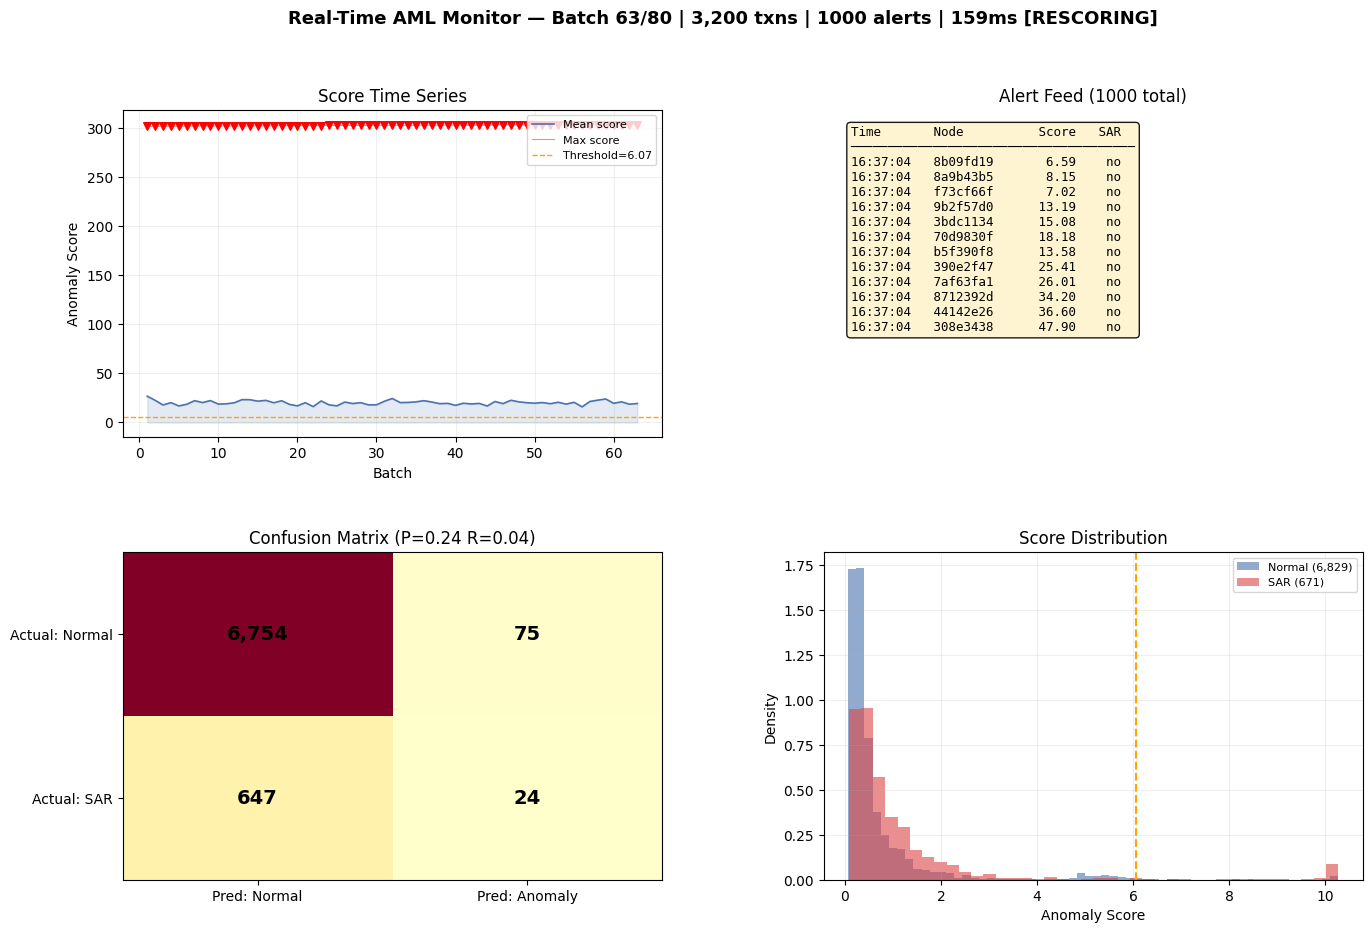

Batch 63: 54 txns (4 laundering) | 42 nodes affected | 17 new alerts | 159ms

Simulation stopped at batch 63

Simulation complete: 48.6s total


In [10]:
# ═══════════════════════════════════════════════════════════
#  SIMULATION LOOP — Live Scoring
# ═══════════════════════════════════════════════════════════

print("Starting real-time simulation...")
sim_start = time.perf_counter()

try:
    for batch_num in range(1, NUM_BATCHES + 1):
        # 1. Generate transactions
        txn_batch = stream.next_batch(BATCH_SIZE)

        # 2. Update graph state
        affected = graph.update(txn_batch)

        # 3. Score affected nodes
        result = scorer.score(graph, affected, batch_num, txn_batch)

        # 4. Render dashboard
        render_dashboard(scorer, graph, batch_num, result, txn_batch)

        # 5. Pace the simulation
        if batch_num < NUM_BATCHES:
            time.sleep(BATCH_INTERVAL)

except KeyboardInterrupt:
    print(f"\nSimulation stopped at batch {batch_num}")

sim_elapsed = time.perf_counter() - sim_start
print(f"\nSimulation complete: {sim_elapsed:.1f}s total")

In [ ]:
# ═══════════════════════════════════════════════════════════
#  FINAL SUMMARY
# ═══════════════════════════════════════════════════════════

latencies = scorer.latency_history
rescore_lats = [l for i, l in enumerate(latencies) if (i + 1) % RESCORE_INTERVAL == 0 or i == 0]
cached_lats = [l for i, l in enumerate(latencies) if (i + 1) % RESCORE_INTERVAL != 0 and i != 0]

# Confusion matrix on final scores
sar_labels = graph.get_sar_labels()
n_scores = min(len(scorer.all_scores), len(sar_labels))
predicted = (scorer.all_scores[:n_scores] > scorer.threshold).astype(int)
actual = sar_labels[:n_scores]
tp = int(((predicted == 1) & (actual == 1)).sum())
fp = int(((predicted == 1) & (actual == 0)).sum())
fn = int(((predicted == 0) & (actual == 1)).sum())
tn = int(((predicted == 0) & (actual == 0)).sum())

print("=" * 65)
print("  REAL-TIME SIMULATION SUMMARY")
print("=" * 65)
print(f"\n  Duration:           {sim_elapsed:.1f}s")
print(f"  Batches:            {stream.batch_num}")
print(f"  Transactions:       {graph.total_txns_processed:,}")
print(f"  Patterns injected:  {stream.total_patterns_injected}")
print(f"  Pattern nodes:      {len(graph.pattern_nodes)} (new SAR markers)")
print(f"\n  {'Detection':^30}")
print(f"  {'-'*30}")
print(f"  Total alerts:       {scorer.total_alerts}")
print(f"  True Positives:     {tp}")
print(f"  False Positives:    {fp}")
print(f"  False Negatives:    {fn}")
print(f"  True Negatives:     {tn}")
print(f"  Precision:          {tp / max(tp + fp, 1):.4f}")
print(f"  Recall:             {tp / max(tp + fn, 1):.4f}")
print(f"  F1:                 {2*tp / max(2*tp + fp + fn, 1):.4f}")
print(f"\n  {'Latency':^30}")
print(f"  {'-'*30}")
print(f"  Mean (all):         {np.mean(latencies):.0f}ms")
if rescore_lats:
    print(f"  Mean (rescore):     {np.mean(rescore_lats):.0f}ms")
if cached_lats:
    print(f"  Mean (cached):      {np.mean(cached_lats):.0f}ms")
print(f"  Max:                {np.max(latencies):.0f}ms")
print(f"  P95:                {np.percentile(latencies, 95):.0f}ms")
print(f"  Throughput:         {graph.total_txns_processed / sim_elapsed:.0f} txns/sec")
print("=" * 65)

# ── Save simulation results to disk ──────────────────────────────
simulation_summary = {
    "run_id": os.environ.get("AML_RUN_ID", "local"),
    "source_run_id": os.environ.get("AML_SOURCE_RUN_ID", None),
    "duration_seconds": round(sim_elapsed, 1),
    "batches_completed": stream.batch_num,
    "total_batches_configured": NUM_BATCHES,
    "total_transactions": graph.total_txns_processed,
    "patterns_injected": stream.total_patterns_injected,
    "pattern_nodes": len(graph.pattern_nodes),
    "detection": {
        "total_alerts": scorer.total_alerts,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "precision": round(tp / max(tp + fp, 1), 4),
        "recall": round(tp / max(tp + fn, 1), 4),
        "f1": round(2*tp / max(2*tp + fp + fn, 1), 4),
    },
    "latency": {
        "mean_all_ms": round(float(np.mean(latencies)), 0),
        "mean_rescore_ms": round(float(np.mean(rescore_lats)), 0) if rescore_lats else None,
        "mean_cached_ms": round(float(np.mean(cached_lats)), 0) if cached_lats else None,
        "max_ms": round(float(np.max(latencies)), 0),
        "p95_ms": round(float(np.percentile(latencies, 95)), 0),
        "throughput_txns_per_sec": round(graph.total_txns_processed / sim_elapsed, 0),
    },
    "threshold": float(scorer.threshold),
    "config": {
        "batch_size": BATCH_SIZE,
        "num_batches": NUM_BATCHES,
        "pattern_prob": PATTERN_PROB,
        "rescore_interval": RESCORE_INTERVAL,
        "threshold_percentile": THRESHOLD_PERCENTILE,
    },
}

# Save summary JSON
with open(os.path.join(SIM_DIR, "simulation_summary.json"), "w") as f:
    json.dump(simulation_summary, f, indent=2)
print(f"\nSummary saved: {SIM_DIR}/simulation_summary.json")

# Save alert log as parquet
if scorer.alerts:
    alert_df = pd.DataFrame(list(scorer.alerts))
    alert_df.to_parquet(os.path.join(SIM_DIR, "alert_log.parquet"), index=False)
    print(f"Alert log saved: {len(alert_df)} alerts")

# Save score time series as parquet
if scorer.score_history:
    score_ts_df = pd.DataFrame(
        list(scorer.score_history),
        columns=["batch", "mean_score", "max_score", "n_alerts"],
    )
    score_ts_df.to_parquet(os.path.join(SIM_DIR, "score_timeseries.parquet"), index=False)
    print(f"Score timeseries saved: {len(score_ts_df)} batches")

# Save latency data
latency_df = pd.DataFrame({
    "batch": list(range(1, len(latencies) + 1)),
    "latency_ms": latencies,
    "is_rescore": [(i % RESCORE_INTERVAL == 0 or i == 1) for i in range(1, len(latencies) + 1)],
})
latency_df.to_parquet(os.path.join(SIM_DIR, "latency.parquet"), index=False)
print(f"Latency data saved: {len(latency_df)} batches")

In [ ]:
# ═══════════════════════════════════════════════════════════
#  Alert Investigation — Top flagged node ego-graph
# ═══════════════════════════════════════════════════════════

if scorer.alerts:
    # Pick highest-scoring alert
    top_alert = max(scorer.alerts, key=lambda a: a["score"])
    top_node = top_alert["node_id"]
    top_idx = graph.node_to_idx.get(top_node)

    print(f"Top Alert: node={top_node}, score={top_alert['score']:.4f}, SAR={top_alert['is_sar']}")

    # Build adjacency list ONCE — O(E) but only once instead of twice
    adj_out = defaultdict(set)  # node_idx → set of dst indices
    adj_in = defaultdict(set)   # node_idx → set of src indices
    for s, d in graph.edges:
        adj_out[s].add(d)
        adj_in[d].add(s)

    # 1-hop neighbors — O(degree) lookup
    neighbors = adj_out.get(top_idx, set()) | adj_in.get(top_idx, set())
    subgraph_indices = {top_idx} | neighbors

    # Pre-build idx→node_id map for subgraph nodes
    idx_to_node = {i: graph.node_ids[i] for i in subgraph_indices if i < len(graph.node_ids)}

    # Build NetworkX subgraph — only check edges from subgraph nodes
    G_nx = nx.DiGraph()
    for idx in subgraph_indices:
        for d in adj_out.get(idx, set()):
            if d in subgraph_indices:
                G_nx.add_edge(idx_to_node.get(idx, str(idx))[:6],
                              idx_to_node.get(d, str(d))[:6])

    if G_nx.number_of_nodes() > 0:
        fig, ax = plt.subplots(figsize=(10, 7))

        # Build reverse lookup: short_id → full_id (only for subgraph nodes)
        short_to_full = {graph.node_ids[i][:6]: graph.node_ids[i] for i in subgraph_indices if i < len(graph.node_ids)}

        # Color: red=top alert, orange=SAR neighbor, blue=clean
        colors = []
        sizes = []
        for n in G_nx.nodes():
            if n == top_node[:6]:
                colors.append("#DD4444")
                sizes.append(800)
            else:
                full_id = short_to_full.get(n)
                if full_id and graph.is_sar.get(full_id, 0):
                    colors.append("#E67E22")
                    sizes.append(500)
                else:
                    colors.append("#AED6F1")
                    sizes.append(400)

        pos = nx.spring_layout(G_nx, k=1.5, seed=42)
        nx.draw_networkx_nodes(G_nx, pos, ax=ax, node_color=colors, node_size=sizes, edgecolors="black", linewidths=0.5)
        nx.draw_networkx_labels(G_nx, pos, ax=ax, font_size=7)
        nx.draw_networkx_edges(G_nx, pos, ax=ax, edge_color="gray", arrows=True, arrowsize=12, alpha=0.6)

        ax.set_title(f"Top Alert Ego-Graph: {top_node[:8]} (score={top_alert['score']:.2f}, {G_nx.number_of_nodes()} nodes)", fontsize=12)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

        print(f"  1-hop neighbors: {len(neighbors)}")
        print(f"  Subgraph edges: {G_nx.number_of_edges()}")
    else:
        print("  No edges found for this node.")

    del adj_out, adj_in  # free memory
else:
    print("No alerts generated during simulation.")

In [ ]:
# ═══════════════════════════════════════════════════════════
#  Latency Analysis
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: latency per batch
batch_nums = list(range(1, len(latencies) + 1))
rescore_mask = [(i % RESCORE_INTERVAL == 0 or i == 1) for i in batch_nums]
colors_lat = ["#DD4444" if r else "#4C72B0" for r in rescore_mask]

axes[0].bar(batch_nums, latencies, color=colors_lat, alpha=0.7, width=0.8)
axes[0].axhline(np.mean(latencies), color="green", linestyle="--", label=f"Mean: {np.mean(latencies):.0f}ms")
axes[0].set_xlabel("Batch")
axes[0].set_ylabel("Latency (ms)")
axes[0].set_title("Scoring Latency per Batch (red=rescore, blue=cached)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# Right: latency histogram
axes[1].hist(latencies, bins=30, color="#4C72B0", alpha=0.7, edgecolor="white")
axes[1].axvline(np.percentile(latencies, 95), color="red", linestyle="--", label=f"P95: {np.percentile(latencies, 95):.0f}ms")
axes[1].axvline(np.mean(latencies), color="green", linestyle="--", label=f"Mean: {np.mean(latencies):.0f}ms")
axes[1].set_xlabel("Latency (ms)")
axes[1].set_ylabel("Count")
axes[1].set_title("Latency Distribution")
axes[1].legend(fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(SIM_DIR, "latency_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Target: <500ms per batch → {'PASS' if np.percentile(latencies, 95) < 500 else 'REVIEW'}")
print(f"Latency plot saved to {SIM_DIR}/latency_analysis.png")

In [14]:
# ── GPU Cleanup ──
del scorer.sage, scorer.encoder, scorer.generator
del scorer
torch.cuda.empty_cache()
gc.collect()
print(f"GPU freed: {torch.cuda.memory_allocated()/1e6:.1f} MB")

GPU freed: 8.5 MB
